### 串行分支

In [12]:
from langchain_core.messages import AIMessage, AnyMessage
from langgraph.graph import START,END,StateGraph
from typing_extensions import TypedDict

class State(TypedDict):
    value_1:str
    value_2:str

def node_1(state:State):
    return {"value_1":"hello"}

def node_2(state:State):
    return {"value_1": f"{state['value_1']} world"}

def node_3(state:State):
    return {"value_2": "欢迎来到agent世界！"}

from langgraph.graph import StateGraph
graph = StateGraph(State)

graph.add_node(node_1)
graph.add_node(node_2)
graph.add_node(node_3)

graph.add_edge(START,"node_1")
graph.add_edge("node_1","node_2")
graph.add_edge("node_2","node_3")
graph.add_edge("node_3",END)

graph_builder = graph.compile()

输出流程图

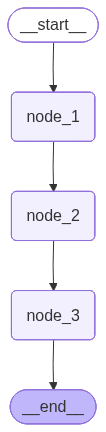

In [13]:
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [15]:
# 执行
result = graph_builder.invoke({})
result

{'value_1': 'hello world', 'value_2': '欢迎来到agent世界！'}

### 条件分支

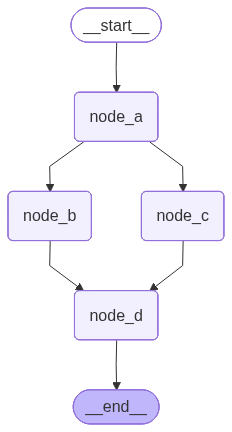

In [ ]:
import operator
from langgraph.graph import START,END,StateGraph
from langchain_core.messages import AIMessage, AnyMessage
from typing_extensions import TypedDict
from typing import Any,Annotated

class State(TypedDict):
    messages: Annotated[list, operator.add]

def node_a(state:State):
    return {"messages": ["A"]}

def node_b(state:State):
    return {"messages": ["B"]}

def node_c(state:State):
    return {"messages": ["C"]}

def node_d(state:State):
    return {"messages": ["D"]}

graph = StateGraph(State)

graph.add_node(node_a)
graph.add_node(node_b)
graph.add_node(node_c)
graph.add_node(node_d)

graph.add_edge(START,"node_a")
graph.add_edge("node_a","node_b")
graph.add_edge("node_a","node_c")
graph.add_edge("node_b","node_d")
graph.add_edge("node_c","node_d")
graph.add_edge("node_d",END)

graph_builder = graph.compile()

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))




In [ ]:
result = graph_builder.invoke({"messages":[]})
result


{'messages': ['A', 'B', 'C', 'D']}

### 分支&&循环


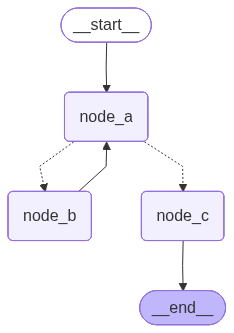

In [77]:
import operator
from langgraph.graph import START,END,StateGraph
from langchain_core.messages import AIMessage, AnyMessage
from typing_extensions import TypedDict
from typing import Any,Annotated,Literal

class State(TypedDict):
    messages: Annotated[list, operator.add]

def node_a(state:State):
    return {"messages": ["A"]}

def node_b(state:State):
    return {"messages": ["B"]}

def node_c(state:State):
    return {"messages": ["C"]}

def route(state:State) -> Literal["node_b","node_c"]:
    return "node_b" if len(state["messages"]) < 5 else "node_c"

graph = StateGraph(State)

graph.add_node(node_a)
graph.add_node(node_b)
graph.add_node(node_c)

graph.add_edge(START,"node_a")
graph.add_conditional_edges("node_a",route)
graph.add_edge("node_b","node_a")
graph.add_edge("node_c",END)

graph_builder = graph.compile()
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [78]:
graph_builder.invoke({"messages":[]})

{'messages': ['A', 'B', 'A', 'B', 'A', 'C']}